In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import pickle

In [2]:
data = pd.read_csv("../dataset/clean_data.csv")

In [3]:
df = data.copy()

In [4]:
ages = df['required_age'].values
names = df['name'].values

In [5]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
log_cols = ["recommendations", "positive_reviews", "negative_reviews", "estimated_owners", "peak_ccu", "avg_playtime_forever", "avg_playtime_2weeks", "median_playtime", "dlc_count", "achievements"]

df[log_cols] = np.log1p(df[log_cols])

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [6]:
X = df.drop(columns=["name"])

In [7]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)

In [8]:
print("Original shape:", X.shape)
print("After PCA:", X_pca.shape)
print(f"Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

Original shape: (1448, 2712)
After PCA: (1448, 359)
Explained Variance: 95.01%


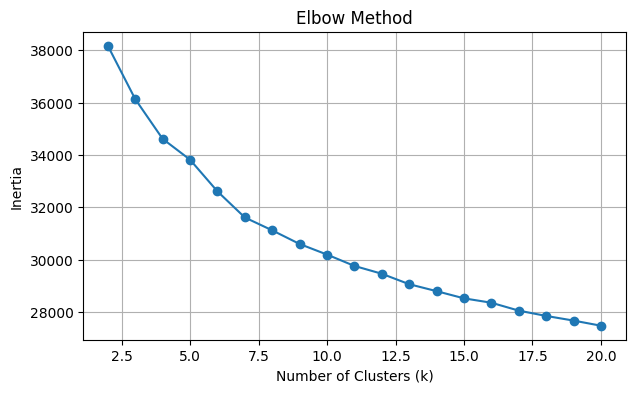

In [9]:
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 21):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(2,21), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [10]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_pca)

In [11]:
df["cluster"] = clusters

df["cluster"].value_counts()

cluster
3    391
4    316
6    210
2    182
0    144
5    129
1     76
Name: count, dtype: int64

In [12]:
knn = NearestNeighbors(n_neighbors=6, metric="cosine")
knn.fit(X_pca)

NearestNeighbors(metric='cosine', n_neighbors=6)

In [13]:
model_data = {
    'knn': knn,
    'X_pca': X_pca,
    'clusters': clusters,
    'names': names,
    'ages': ages
}

In [14]:
with open('../model/model.pkl', 'wb') as f:
    pickle.dump(model_data, f)